In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


In [ ]:

# 1. Most frequently used model and reasons
# 2. Most frequently asked domain and properties
# 3. Using regression, analyze the relative importance of factors and produce a influence matrix
# 4. Give a thorough explanation and visualization on different models' performance over different dimensions
# 5. Least hallucinated model
# 6. Relationship between prompt length and token cross models
# 7. Relationship between application domain and estimated cost
# 8. Most financially efficient model and the least
# 9. Most satisfactory model
# 10. Relationship between temperature and hallucination

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving genai_llm_usage_dataset_1000.csv to genai_llm_usage_dataset_1000.csv


In [ ]:
llm_usage = pd.read_csv("/content/genai_llm_usage_dataset_1000.csv")

In [ ]:
llm_usage

,session_id,model_name,application_domain,task_type,prompt_length,total_tokens,temperature,top_p,rag_enabled,latency_sec,hallucination_flag,user_satisfaction,estimated_cost_usd,successful_response
0,1,GPT-4o,Healthcare,Summarization,1319,2455,0.17,0.87,0,3.76,0,4,0.0236,1
1,2,GPT-4o,Customer Support,Summarization,486,1425,0.76,0.51,0,2.36,1,5,0.0236,0
2,3,Gemma 3,Retail,Classification,1439,1648,0.63,0.64,0,3.68,1,4,0.0139,0
3,4,Gemma 3,Retail,Summarization,1662,2812,0.07,0.73,0,3.25,1,4,0.0374,0
4,5,Gemma 3,Finance,Classification,1452,1678,0.10,0.83,0,8.04,0,4,0.0171,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Llama 3.1,Retail,QA,696,1044,1.46,0.95,0,3.99,1,4,0.0076,0
996,997,Qwen 2.5,Finance,RAG,227,1022,0.91,0.90,0,4.47,1,5,0.0026,0
997,998,Claude 3.7,Customer Support,QA,1571,2694,1.50,0.54,1,2.77,0,5,0.0465,1
998,999,Llama 3.1,Customer Support,Classification,1253,2451,0.71,0.76,0,5.21,1,4,0.0157,0


In [ ]:
# 1. Most frequently used model

llm_frequency = llm_usage["model_name"].value_counts() # count by model, auto-sort descending

llm_frequency.head(3)

,count
model_name,
Mistral Large,193
Qwen 2.5,177
GPT-4o,167


In [ ]:

# 2. Most frequently asked domain

llm_domain = llm_usage["application_domain"].value_counts() # count by domain, auto-descending

llm_domain.head(3)

,count
application_domain,
Customer Support,165
Education,156
Retail,154


In [ ]:

# 3. Using regression, analyze the relative importance of factors and produce a influence matrix

'''
Define Factors:
- domain
- task
- token
- hallucination
- cost

Result -> satisfaction

normalize 5 factors and give the best weight and get the relative importance.

final product -> heat map to represent relative importance

>=1 -> red
<1 -> blue


'''
# First convert qualitative data into quantitative by giving the score of average for the result with different groups
domain_means = llm_usage.groupby('application_domain')['user_satisfaction'].mean()
task_means = llm_usage.groupby('task_type')['user_satisfaction'].mean()
# Load the scores and use for regression
llm_usage['domain_enc'] = llm_usage['application_domain'].map(domain_means)
llm_usage['task_enc'] = llm_usage['task_type'].map(task_means)

f_c = ['domain_enc', 'task_enc', 'total_tokens', 'hallucination_flag', 'estimated_cost_usd'] # dimensions
t_c = 'user_satisfaction' # result






In [ ]:
def analyze_model_importance(llm_data):
    # define var
    x = llm_data[f_c].copy()
    y = llm_data[t_c]
    # drop and seperate dim
    c_c = [col for col in x.columns if x[col].std() == 0]
    if c_c:
        x = x.drop(columns=c_c)
    else:
        c_c = []

    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x)
    # Regression
    lr = LinearRegression()
    lr.fit(x_scaled, y)
    # construct importance matrix
    co_dict = dict(zip(x.columns, lr.coef_))
    for col in c_c:
        co_dict[col] = 0.0

    co_list = [co_dict.get(col, 0.0) for col in f_c]
    # Other results
    m_co = np.mean(np.abs(co_list))
    if m_co == 0:
        r_i = [0.0] * len(f_c)
    else:
        r_i = [c / m_co for c in co_list]

    return co_list, r_i, f_c

In [ ]:
llms = llm_usage['model_name'].unique()
results = []
# Show by models
for llm in llms:
    model = llm_usage[llm_usage['model_name'] == llm]

    coefs, rels, f_names = analyze_model_importance(model)

    row = {'model_name': llm}
    template = {
        'domain_enc': 'Domain',
        'task_enc': 'Task',
        'total_tokens': 'Token',
        'hallucination_flag': 'Hallucination',
        'estimated_cost_usd': 'Cost'
    }
    for i, f in enumerate(f_names):
        row[f'rel_{template[f]}'] = rels[i]
    results.append(row)

result = pd.DataFrame(results)

print(result.round(3))

      model_name  rel_Domain  rel_Task  rel_Token  rel_Hallucination  rel_Cost
0         GPT-4o       0.598    -0.474     -0.095             -2.990    -0.843
1        Gemma 3       1.833     0.609     -0.295             -0.539    -1.724
2  Mistral Large       0.580     1.105      0.539             -0.923    -1.852
3     Claude 3.7       0.926     0.909     -1.070             -1.353     0.743
4      Llama 3.1       1.074     1.462      0.390             -0.875     1.199
5       Qwen 2.5       1.264     0.569      0.112             -1.625    -1.430


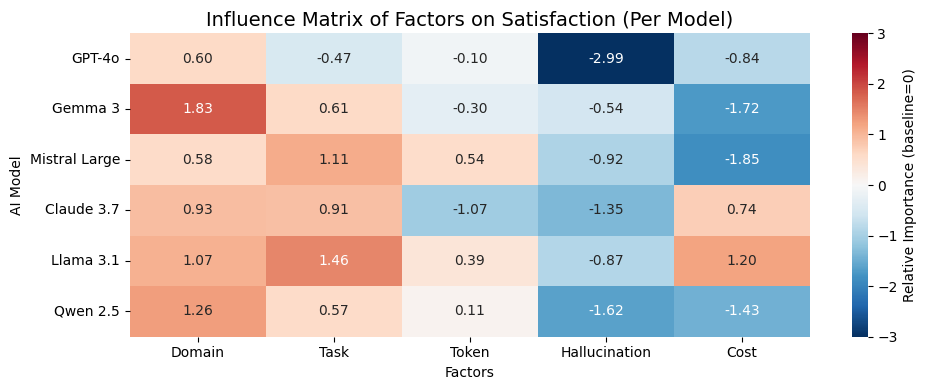

In [ ]:

# Vis
map_data = result.set_index('model_name')
map_data = map_data[[col for col in map_data.columns if col.startswith('rel_')]]
map_data.columns = [col.replace('rel_', '') for col in map_data.columns]

plt.figure(figsize=(10, max(4, len(llms) * 0.5)))
sns.heatmap(
    map_data,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-3, #For negatively correlated
    vmax=3, #For positively correlated
    cbar_kws={'label': 'Relative Importance (baseline=0)'}
)
plt.title('Influence Matrix of Factors on Satisfaction (Per Model)', fontsize=14)
plt.xlabel('Factors')
plt.ylabel('AI Model')
plt.tight_layout()
plt.show()

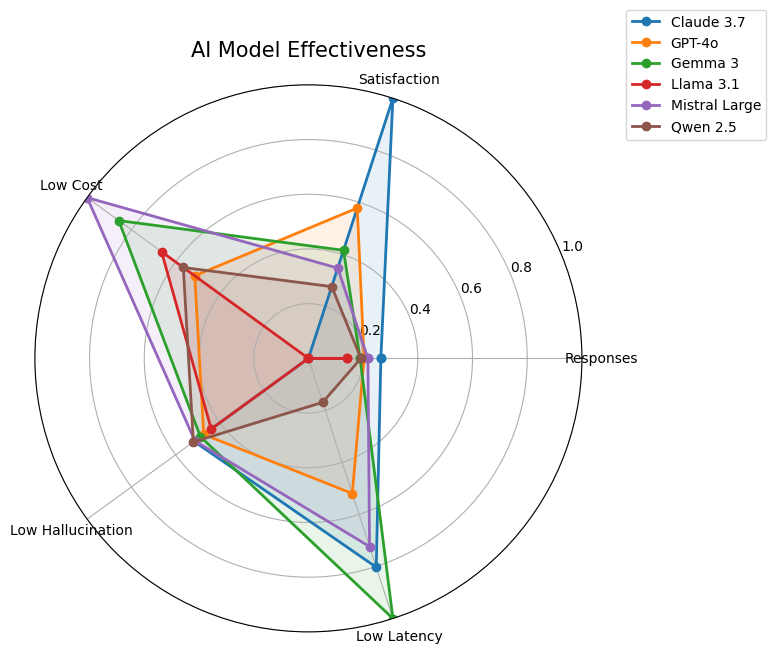

In [ ]:
# 4. Give a thorough explanation and visualization on different models' performance over different dimensions such as application domain, task type
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load all avg values
df = llm_usage.groupby("model_name").agg(
    responses=("successful_response", "mean"),
    satisfaction=("user_satisfaction", "mean"),
    cost=("estimated_cost_usd", "mean"),
    hallucination=("hallucination_flag", "mean"),
    latency_sec=("latency_sec", "mean")
)
df["cost_score"] = 1 - (
    (df["cost"] - df["cost"].min()) /
    (df["cost"].max() - df["cost"].min())
)   # Normalize, negative
df["hallucination_score"] = 1 - df["hallucination"] #negative

df["latency_score"] = 1 - (
    (df["latency_sec"] - df["latency_sec"].min()) /
    (df["latency_sec"].max() - df["latency_sec"].min())
) #Normalize, negative
df["satisfaction_score"] = (
    (df["satisfaction"] - df["satisfaction"].min()) /
    (df["satisfaction"].max() - df["satisfaction"].min())
) #Normalize, positive
radar_df = df[
    [
        "responses",
        "satisfaction_score",
        "cost_score",
        "hallucination_score",
        "latency_score"
    ]
].copy() # For Vis
radar_df.columns = [
    "Responses",
    "Satisfaction",
    "Low Cost",
    "Low Hallucination",
    "Low Latency"
]
labels = radar_df.columns.tolist()
num_vars = len(labels)
# Define 5 dimensions and dir
angles = np.linspace(
    0,
    2 * np.pi,
    num_vars,
    endpoint=False
).tolist()
angles += angles[:1]
fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw={"polar": True}
)
for model_name, row in radar_df.iterrows():
    values = row.tolist()
    values += values[:1]
    ax.plot(
        angles,
        values,
        marker="o",
        linewidth=2,
        label=model_name
    )
    ax.fill(
        angles,
        values,
        alpha=0.1
    )
ax.set_thetagrids(
    np.degrees(angles[:-1]),
    labels
)
ax.set_ylim(0, 1)
ax.set_title(
    "AI Model Effectiveness",
    fontsize=15,
    pad=20
)
ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.35, 1.15)
)
plt.tight_layout()
plt.show()

In [ ]:

# 5. Least hallucination model
hallucinations = llm_usage[llm_usage["hallucination_flag"] == 1]["model_name"].value_counts() # Count Hallu
total = llm_usage["model_name"].value_counts()
hallucination_rate=(hallucinations/total) # Avg over model usage
print(hallucination_rate.sort_values().to_markdown(tablefmt="grid")) # vis

+---------------+----------+
| model_name    |    count |
+===============+==========+
| Qwen 2.5      | 0.480226 |
+---------------+----------+
| Claude 3.7    | 0.483444 |
+---------------+----------+
| Mistral Large | 0.487047 |
+---------------+----------+
| Gemma 3       | 0.512195 |
+---------------+----------+
| GPT-4o        | 0.526946 |
+---------------+----------+
| Llama 3.1     | 0.560811 |
+---------------+----------+


prompt_length_groups
0-100         645.354839
101-200       786.982143
201-300       927.058824
301-400      1049.028571
401-500       986.489362
501-600      1128.782609
601-700      1194.684211
701-800      1257.310345
801-900      1423.937500
901-1000     1580.000000
1001-1100    1653.391304
1101-1200    1785.865385
1201-1300    1817.593220
1301-1400    2023.400000
1401-1500    2007.031746
1501-1600    2190.108696
1601-1700    2306.787234
1701-1800    2380.645833
1801-1900    2584.387755
1901-2000    2557.169811
Name: total_tokens, dtype: float64


/tmp/ipykernel_2042/3139367880.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_averages = llm_usage.groupby('prompt_length_groups')['total_tokens'].mean()


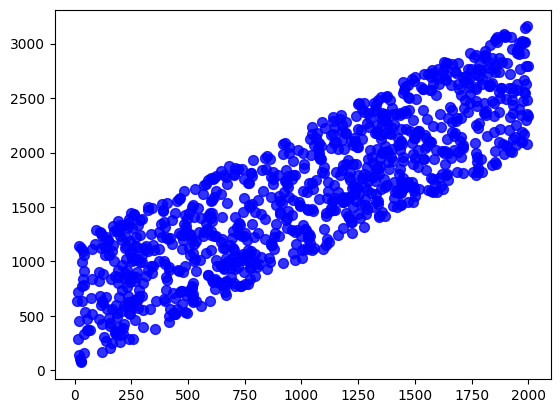

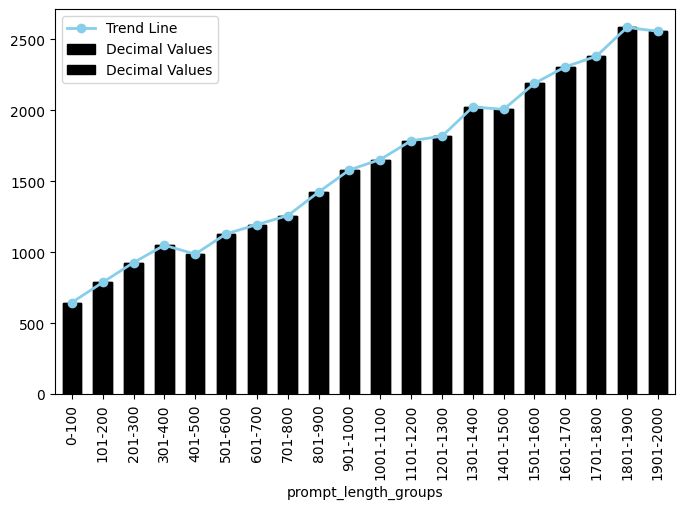

In [ ]:

# 6. Relationship between prompt_length and token

#create a scatter plot to visualize the relationship between prompt_length and total_tokens
plt.scatter(llm_usage['prompt_length'], llm_usage['total_tokens'], color='blue', marker='o', s=50, alpha=0.8)

#create bins for prompt_length (in intervals of 100)
bin_arr = [0,100,200,300,400, 500, 600, 700, 800, 900, 1000, 1100,1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000]
labels_arr = ["0-100", "101-200", "201-300","301-400","401-500","501-600","601-700","701-800","801-900","901-1000",'1001-1100', '1101-1200','1201-1300','1301-1400','1401-1500','1501-1600','1601-1700','1701-1800', '1801-1900', '1901-2000']

#using the .cut function to create a new column in the dataframe that categorizes the prompt_length into the defined bins
llm_usage['prompt_length_groups'] = pd.cut(llm_usage['prompt_length'], bins=bin_arr, labels=labels_arr, right=False)

#finding the mean of total_tokens for each prompt_length group
group_averages = llm_usage.groupby('prompt_length_groups')['total_tokens'].mean()
print(group_averages)


#plotting the bar chart with a trend line
fig, ax = plt.subplots(figsize=(8, 5))


# df.plot(kind='bar', x='labels', y='tokens', ax=ax, color='black',
#         edgecolor='black', width=0.6, zorder=2, label='Decimal Values')

#making a bar chart with a trend line to visualize the relationship between prompt_length and total_tokens
group_averages.plot(kind='bar', x='labels', y='tokens', ax=ax, color='black',
        edgecolor='black', width=0.6, zorder=2, label='Decimal Values')

x_pos = range(len(group_averages))
ax.bar(x_pos, group_averages.values, color='black', edgecolor='black', width=0.6, zorder=2, label='Decimal Values')
ax.plot(x_pos, group_averages.values, color='skyblue', marker='o', linewidth=2, markersize=6, zorder=3, label='Trend Line')
ax.set_xticks(x_pos)
ax.set_xticklabels(group_averages.index)
ax.legend()





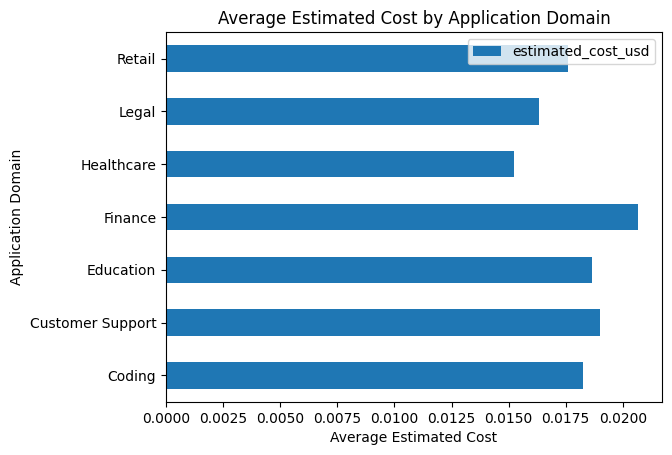

In [ ]:

# 7. Relationship between application domain and estimated cost

#Get dataframe by grouping all application domain and averaging their estimated cost to run
df=pd.DataFrame(llm_usage.groupby("application_domain")["estimated_cost_usd"].mean())
#make a horizontal bar graph
ax = df.plot(kind="barh")
#display with mantplotlib and set labels
ax.set_xlabel("Average Estimated Cost")
ax.set_ylabel("Application Domain")
ax.set_title("Average Estimated Cost by Application Domain")

plt.show()


In [ ]:

# 8. Most financially efficient model and the least

#setting the precision of the display to 12 decimal places for comparative purposes
pd.set_option("display.precision", 12)

#using column division to calculate the cost per token for each model
llm_usage['cost_tokens_ratio'] = llm_usage['estimated_cost_usd']/llm_usage['total_tokens']

#taking the mean of the cost per token for each model
average = llm_usage.groupby('model_name')[['cost_tokens_ratio']].mean()

#visualizing results
print(average)



               cost_tokens_ratio
model_name                      
Claude 3.7        0.000011480711
GPT-4o            0.000010623862
Gemma 3           0.000010592193
Llama 3.1         0.000011131765
Mistral Large     0.000011010121
Qwen 2.5          0.000010879734


In [ ]:

# 9. Most satisfactory model

llm_usage.groupby("model_name")["user_satisfaction"].mean().head(3)



,user_satisfaction
model_name,
Claude 3.7,4.470198675497
GPT-4o,4.377245508982
Gemma 3,4.341463414634


a:96
b:93
a:187
b:91
a:301
b:114
a:392
b:91
a:514
b:122
a:617
b:103
a:706
b:89
a:815
b:109
a:905
b:90
a:995
b:90


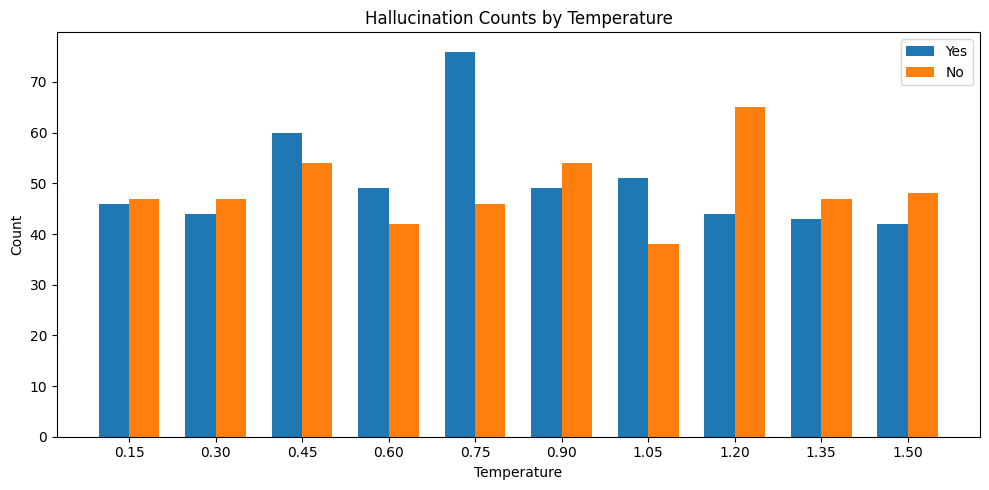

In [ ]:

# 10. Relationship between temperature and hallucination
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv("genai_llm_usage_dataset_1000.csv")
sort = df["temperature"].sort_values().unique()
lower = sort[0]
last = sort[len(sort)-1]
space = (last - lower)/10
groups = np.arange(lower+space, last+space, space)
last_v = 0.0
dic = {}
for v in groups:
    a = df[df["temperature"]<=v]
    print(f"a:{len(a)}")
    b = a[a["temperature"]> last_v]
    print(f"b:{len(b)}")
    yes = len(b[b["hallucination_flag"] == 1])
    no =  len(b[b["hallucination_flag"] == 0])
    dic[v] = [yes, no]
    last_v = v
temps = list(dic.keys())
yes = [p[0] for p in dic.values()]
no = [p[1] for p in dic.values()]
x = range(len(temps))
width = 0.35
plt.figure(figsize=(10, 5))
plt.bar([i - width/2 for i in x], yes, width=width, label="Yes")
plt.bar([i + width/2 for i in x], no, width=width, label="No")
plt.xticks(x, [f"{t:.2f}" for t in temps])
plt.xlabel("Temperature")
plt.ylabel("Count")
plt.title("Hallucination Counts by Temperature")
plt.legend()
plt.tight_layout()
plt.show()

Answers for all our question above

1. Most frequently used model

By this dataset, Mistral Large is the most frequently used LLM

This may be related to its lowest cost and 2nd lowest latency compared to other LLMs



2. Most frequently asked domain

By this dataset, the most frequently asked domain is customer support.

This can be explained by the increasingly convenient online buying experience, where more and more people choose to buy things online.

Thus, an increased demand for customized support led to use of AI.


3. Using regression, we analyzed the relative importance of factors and produce a influence matrix

As expected, the most important factor for satisfaction is the domain of query, and the most important factor for de-satisfaction is hallucination and cost.

The domain greatly influenced the expectation, and the hallucination or a high cost will greatly underscore the response.

4. Give a thorough explanation and visualization on different models' performance over different dimensions such as application domain, task type

By the graph, different models displayed high score on different dimensions.

Claude did the best on Satisfaction and Responses

Mistral Large did the best on low cost

Qwen did the best on low hallucination

Gemma 3 did the best on low latency

All LLMs did not perform well on Responses and low Hallucination

Llama 3.1 is the worst in general, while Mistral Large and Gemma are the best in general.


5. Least hallucinated model

We analyzed the model that had the least hallucination rate or the lowest rate of generating confident false answers. We found the Qwen2.5 had the lowest rate while Llama3.1 had the highest rate. The average hallucination rate of models in the data set is 0.50844483333.

6. Relationship between prompt_length and token

We investigated the relationship between prompt length and  token usage, to understand which models were able to efficiently answer questions. We started by creating a scatter plot to visualize the general trend, and found that there was a direct, linear relationship between the two

Prompt length and tokens approximately positively correlated, but with some fluctuations that could be the result of difference of data density and context.

7. Relationship between application domain and estimated cost

We analyzed the relationship between the application’s domain and estimated cost that was used for the model to generate an answer. The results were that healthcare cost the least on average while finance cost the most.

8. Most financially efficient model and the least

We decided to investigate which models were the most financially efficient
Initially, we considered plotting the total cost against the prompt length
However, this would fail to account for the model’s efficiency while creating its output, so we chose to use total tokens instead of prompt length
After using taking the average value of the quotient of the cost and token count columns across models, we printed the results as shown
We found that although most of them were relatively similar, Gemma 3 was the most efficient and Claude 3.7 was the least efficient


9. Most satisfactory model

By the dataset, the model that most users are satisfied with its responses is Claude 3.7

This could be explained by Claude’s main tasks being writing code.

Coding, a skill not very common among people, is very important in data processing, etc. Thus, with help of LLM, most coding tasks can be finished in a few minutes, thus bringing the most satisfaction.

10. Relationship between temperature and hallucination

By the dataset, there’s a significant fluctuation of appearance of hallucination around temperature of 0.45 to 1.35, while the lower temperature, like 0.15 displayed no great difference on the hallucination.

This could imply that temperature somehow influenced the net work so that the responses are less stable on its reliability.



